# 03 — Experimental pipeline: 2.5D conditional localization models

This orchestration notebook trains one of the four model definitions on one of the two dataset variants.

Dataset variants:

- `no_aug`
- `intensity_aug`

Models:

- `unet`
- `attention_unet`
- `unetr`
- `swin_unet`

## 1. Imports and reusable definitions

In [1]:
import os
from pathlib import Path
import math
import time
import random
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from PIL import Image, ImageOps
import pydicom

In [2]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

## 2. Configuration

In [3]:
# Central configuration variables
# Edit these values here instead of changing parameters throughout the notebook.
BASE_DIR = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = BASE_DIR / "BC-data" / "data-rsna2024"
DATA_MERGED_CSV = DATA_ROOT / "data_merged.csv"
OUTPUT_DIR = BASE_DIR / "Localization-baseline" / "models" / "spinal_axial_localization"
CURRENT_DIR = BASE_DIR / "Localization-baseline"

FUNCTIONS_NOTEBOOK = CURRENT_DIR / "200_vertebra_localization_functions.ipynb"
DATASETS_NOTEBOOK = CURRENT_DIR / "201_vertebra_localization_datasets.ipynb"
MODELS_NOTEBOOK = CURRENT_DIR / "202_vertebra_localization_models.ipynb"

SERIES_DESCRIPTIONS = ("Axial T2",)
CONDITIONS = ("Left Subarticular Stenosis", "Right Subarticular Stenosis")
SIDES = ["Left", "Right"]
LEVELS=SIDES
SIDE_TO_IDX = {"Left": 0, "Right": 1}
IDX_TO_SIDE = {0: "Left", 1: "Right"}

USE_EXTERNAL_LOCALIZATION_COORDS = False
EXTERNAL_COORDS_CSV = BASE_DIR / "BC-data" / "data-pretraining" / "df_coords.csv"
EXTERNAL_IMAGE_ROOT = BASE_DIR / "BC-data" / "data-pretraining"
EXTERNAL_SOURCE_NAME = "external_spider"
EXTERNAL_REPLICATE_SINGLE_SLICE_TO_NUM_SLICES = True
INCLUDE_EXTERNAL_IN_PRIOR_MAPS = False
RSNA_SOURCE_NAME = "rsna"

EXPERIMENT_DATASET = "no_aug"  # "no_aug" or "intensity_aug"
MODEL_NAME = "unet"  # "unet", "attention_unet", "unetr", or "swin_unet"
RANDOM_SEED = 42
VAL_FRAC = 0.15
TEST_FRAC = 0.15

IMG_SIZE = 256
NUM_SLICES = 3
SIGMA = 5.0

BATCH_SIZE = 32
EPOCHS = 40
PATIENCE = 7
LR = 1e-3
WEIGHT_DECAY = 1e-5
BASE_CHANNELS = 32
DROPOUT = 0.0
DYNAMIC_SIGMA = None  # Example: {0: 8.0, 10: 6.0, 20: 4.0}

NUM_WORKERS = 12
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

PRIOR_SIGMA = 8
PRIOR_EPS = 1e-4

FUSION_MODE = "log"
FUSION_LAM = 0.5
FUSION_EPS = 1e-8
PRIOR_X_RELAX_SIGMA = 28.0
PRIOR_Y_RELAX_SIGMA = 0.0

EVAL_TOLERANCE_PX = 10.0
ORDER_MARGIN_PX = 15.0

CORRECTION_TOP_K = 3
CORRECTION_NMS_RADIUS = 8
CORRECTION_MIN_CANDIDATE_SCORE = 0.0
CORRECTION_UNION_MODE = "max"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(BASE_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def seed_everything(seed: int):
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)
    
seed_everything(RANDOM_SEED)
print("Device:", device)


Device: cuda


## Support notebooks

In [5]:
# Reusable definitions and model/dataset notebooks
%run "$FUNCTIONS_NOTEBOOK"
%run "$DATASETS_NOTEBOOK"
%run "$MODELS_NOTEBOOK"

## 3. Load metadata and create study-level split

In [6]:
df_all = pd.read_csv(DATA_MERGED_CSV)
df_loc = df_all[
    (df_all["condition"].isin(CONDITIONS)) &
    (df_all["series_description"].isin(SERIES_DESCRIPTIONS)) &
    (df_all["x"].notna()) &
    (df_all["y"].notna()) &
    (df_all["instance_number"].notna())
].copy()

df_loc["source"] = RSNA_SOURCE_NAME

df_loc["side"] = df_loc["condition"].map({
    "Left Subarticular Stenosis": "Left",
    "Right Subarticular Stenosis": "Right",
})

df_loc["side_idx"] = df_loc["side"].map(SIDE_TO_IDX).astype(int)

df_loc["level_idx"] = df_loc["side"].map({
    "Left": 0,
    "Right": 1,
}).astype(int)
df_loc["source"] = RSNA_SOURCE_NAME

print("All merged rows:", len(df_all))
print("Localization rows after filtering:", len(df_loc))

display(df_loc.head())

print("Studies:", df_loc["study_id"].nunique())
print("Levels:")
display(df_loc["side"].value_counts().reindex(LEVELS))


All merged rows: 48677
Localization rows after filtering: 19220


,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,img_path,image_height,image_width,x_norm,y_norm,source,side,side_idx,level_idx
15,4003253_left_subarticular_stenosis_l1_l2,4003253,2448190387,Left Subarticular Stenosis,L1/L2,Axial T2,3,179.126448,161.235521,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/2...,320,320,0.559770,0.503861,rsna,Left,0,0
16,4003253_right_subarticular_stenosis_l1_l2,4003253,2448190387,Right Subarticular Stenosis,L1/L2,Axial T2,4,145.288771,158.624642,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/2...,320,320,0.454027,0.495702,rsna,Right,1,1
17,4003253_left_subarticular_stenosis_l2_l3,4003253,2448190387,Left Subarticular Stenosis,L2/L3,Axial T2,11,180.979730,158.764479,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/2...,320,320,0.565562,0.496139,rsna,Left,0,0
18,4003253_right_subarticular_stenosis_l2_l3,4003253,2448190387,Right Subarticular Stenosis,L2/L3,Axial T2,11,145.900042,157.096466,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/2...,320,320,0.455938,0.490926,rsna,Right,1,1
19,4003253_left_subarticular_stenosis_l3_l4,4003253,2448190387,Left Subarticular Stenosis,L3/L4,Axial T2,19,176.037645,157.528958,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/2...,320,320,0.550118,0.492278,rsna,Left,0,0


Studies: 1974
Levels:


side
Left     9608
Right    9612
Name: count, dtype: int64

## 3b. Convert external lumbar coordinate CSV into RSNA-like train rows

The external dataset from `Localization_lumbar_spine_aug` is converted to the same long localization format as `data_merged`: one row per image and lumbar level. It is then used only for training, while validation/test remain RSNA-only. Because the external images do not have neighboring-slice metadata, the custom dataset below repeats the same single image across all three 2.5D channels.


In [7]:
# Keep validation/test RSNA-only. External localization rows are train-only.
rsna_train_df, val_df, test_df = split_by_study(df_loc, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=RANDOM_SEED)
train_df = rsna_train_df.copy()

external_loc_df = pd.DataFrame()
if USE_EXTERNAL_LOCALIZATION_COORDS:
    external_loc_df = build_external_localization_df(EXTERNAL_COORDS_CSV, EXTERNAL_IMAGE_ROOT)


print(f"RSNA train rows: {len(rsna_train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"RSNA train studies: {rsna_train_df.study_id.nunique():,} | Val studies: {val_df.study_id.nunique():,} | Test studies: {test_df.study_id.nunique():,}")
print(f"External train-extension rows: {len(external_loc_df):,}")



RSNA train rows: 13,478 | Val rows: 2,893 | Test rows: 2,849
RSNA train studies: 1,382 | Val studies: 296 | Test studies: 296
External train-extension rows: 0


## 4. Create dataset and dataloaders

In [8]:
loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_SEED)

In [9]:
base_cfg = LocalizationDatasetConfig(
    img_size=IMG_SIZE,
    num_slices=NUM_SLICES,
    sigma=SIGMA,
    use_intensity_aug=False,
    seed=RANDOM_SEED,
)

variants = make_dataset_variants(
    train_df=rsna_train_df,
    val_df=val_df,
    test_df=test_df,
    base_config=base_cfg,
)


rsna_train_ds = variants[EXPERIMENT_DATASET]["train"]
val_ds = variants[EXPERIMENT_DATASET]["val"]
test_ds = variants[EXPERIMENT_DATASET]["test"]

external_train_ds = None
if USE_EXTERNAL_LOCALIZATION_COORDS and len(external_loc_df) > 0:
    external_train_ds = ExternalReplicatedSliceLocalizationDataset(
        external_loc_df,
        config=base_cfg,
        levels=LEVELS,
        use_intensity_aug=(EXPERIMENT_DATASET == "intensity_aug"),
    )
    train_ds = MixedLocalizationDataset([rsna_train_ds, external_train_ds])
else:
    train_ds = rsna_train_ds


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

print("Dataset variant:", EXPERIMENT_DATASET)
print("Available variants:", list(variants))
print("Train/val/test samples:", len(train_ds), len(val_ds), len(test_ds))
print("RSNA train samples:", len(rsna_train_ds))
print("External replicated train samples:", 0 if external_train_ds is None else len(external_train_ds))

if hasattr(train_ds, "df") and "source" in train_ds.df.columns:
    print("Train dataset source distribution:")
    display(train_ds.df["source"].value_counts(dropna=False))

sample = train_ds[0]
print(
    "image:", tuple(sample["image"].shape),
    "target:", tuple(sample["target"].shape),
    "level_idx:", sample["level_idx"].item(),
)


Dataset variant: no_aug
Available variants: ['no_aug', 'intensity_aug']
Train/val/test samples: 13478 2893 2849
RSNA train samples: 13478
External replicated train samples: 0
Train dataset source distribution:


source
rsna    13478
Name: count, dtype: int64

image: (3, 256, 256) target: (1, 256, 256) level_idx: 0


In [10]:
prior_train_df = train_ds.df if INCLUDE_EXTERNAL_IN_PRIOR_MAPS else rsna_train_ds.df
print("Prior maps built from rows:", len(prior_train_df))
if "source" in prior_train_df.columns:
    print("Prior-map source distribution:")
    display(prior_train_df["source"].value_counts(dropna=False))

PRIOR_MAPS = build_relative_coordinate_prior_maps_from_norm_cols(
    train_df=prior_train_df,
    img_size=IMG_SIZE,
    sigma=PRIOR_SIGMA,
    levels=LEVELS,
)

prior_maps = PRIOR_MAPS


Prior maps built from rows: 13478
Prior-map source distribution:


source
rsna    13478
Name: count, dtype: int64

Built relative-coordinate priors: (2, 256, 256)
Counts per level: {'Left': 6738, 'Right': 6740}


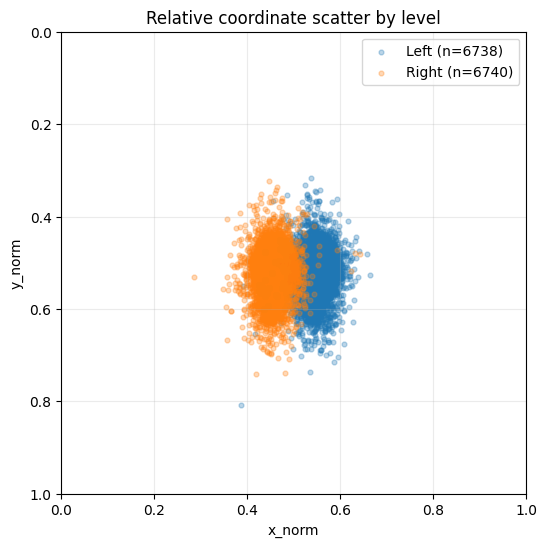

In [11]:
plot_relative_coordinate_scatter_from_norm_cols(
    train_df=train_ds.df,
    levels=LEVELS,
    alpha=0.3, 
    figsize=(6,6)
)

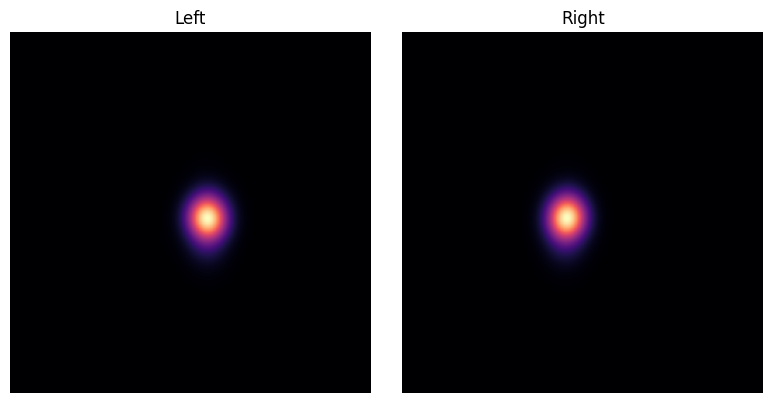

In [12]:
plot_prior_maps(PRIOR_MAPS, levels=LEVELS)

## 5. Model, optimizer, and loss

In [13]:
model = get_localization_model(
    model_name=MODEL_NAME,
    in_channels=NUM_SLICES,
    out_channels=1,
    n_levels=len(LEVELS),
    base_c=BASE_CHANNELS,
    dropout=DROPOUT,
    img_size=IMG_SIZE,
).to(device)

print(model.__class__.__name__)
print(f"Trainable parameters: {count_parameters(model):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

ConditionalUNet
Trainable parameters: 7,797,953


## 6. Training loop

In [14]:
class WeightedHeatmapMSELoss(nn.Module):

    def __init__(self, pos_weight: float):
        super().__init__()
        self.pos_weight = float(pos_weight)

    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        weights = 1.0 + self.pos_weight * target
        return (weights * (pred - target) ** 2).mean()

def coordinate_l2_loss(logits, point_xy, beta: float = 50.0):
    pred_xy = soft_argmax_2d(torch.sigmoid(logits), beta=beta)
    return torch.norm(pred_xy - point_xy, dim=1).mean()
heatmap_loss_fn = WeightedHeatmapMSELoss(pos_weight=20.0)
COORD_LOSS_WEIGHT = 0.02

def compute_loss(logits, batch):
    hm_loss = heatmap_loss_fn(logits, batch['target'])
    xy_loss = coordinate_l2_loss(logits, batch['point_xy'])
    return (hm_loss + COORD_LOSS_WEIGHT * xy_loss, {'heatmap_loss': hm_loss.item(), 'xy_loss': xy_loss.item()})


In [15]:
print("train len:", len(train_ds))
print("val len:", len(val_ds))
print("test len:", len(test_ds))

s = train_ds[0]
print("image sum:", float(s["image"].sum()))
print("target sum:", float(s["target"].sum()))
print("point_xy:", s["point_xy"])
print("level_idx:", s["level_idx"])

s = test_ds[0]
print("TEST image sum:", float(s["image"].sum()))
print("TEST target sum:", float(s["target"].sum()))
print("TEST point_xy:", s["point_xy"])
print("TEST level_idx:", s["level_idx"])

train len: 13478
val len: 2893
test len: 2849
image sum: 38298.4296875
target sum: 157.36526489257812
point_xy: tensor([143.3012, 128.9884])
level_idx: tensor(0)
TEST image sum: 88177.3125
TEST target sum: 157.61492919921875
TEST point_xy: tensor([133.9333, 131.5930])
TEST level_idx: tensor(0)


In [16]:
from tqdm.auto import tqdm

model, history_df, ckpt_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=EPOCHS,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    n_levels=2,
    dynamic_sigma=DYNAMIC_SIGMA
)

display(history_df.tail())
history_csv = OUTPUT_DIR / f"history_{MODEL_NAME}_{EXPERIMENT_DATASET}.csv"
history_df.to_csv(history_csv, index=False)
print("Saved history:", history_csv)

train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 001/40 | train 0.14433 | val 0.06749 | sigma 5.00 | n_levels 2 | 44.7s
  saved: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/spinal_axial_localization/best_unet_no_aug.pt


train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/91 [00:00<?, ?it/s]

...

train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 019/40 | train 0.03874 | val 0.04371 | sigma 5.00 | n_levels 2 | 42.7s
Early stopping.


,epoch,train_loss,val_loss,train_heatmap_loss,val_heatmap_loss,train_xy_loss,val_xy_loss,seconds,sigma,n_levels
14,14,0.046467,0.042798,0.002879,0.002503,2.179389,2.014735,42.712743,5.0,2
15,15,0.041079,0.041124,0.001847,0.001742,1.961563,1.969144,42.419664,5.0,2
16,16,0.039509,0.041244,0.001547,0.001643,1.898140,1.980078,42.469708,5.0,2
17,17,0.039222,0.041110,0.001555,0.001675,1.883345,1.971732,42.464452,5.0,2
18,18,0.038740,0.043710,0.001465,0.002414,1.863759,2.064795,42.719047,5.0,2


Saved history: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/spinal_axial_localization/history_unet_no_aug.csv


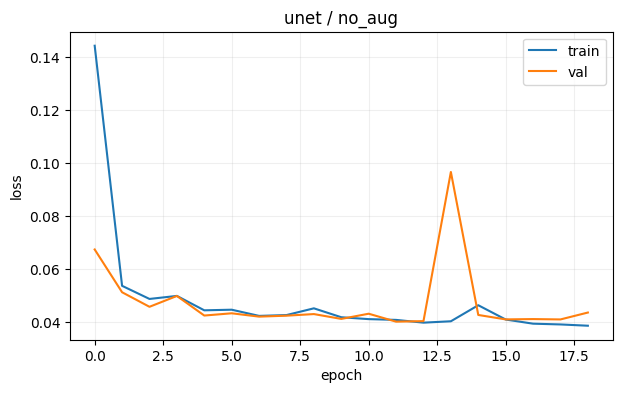

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"{MODEL_NAME} / {EXPERIMENT_DATASET}")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

## 7. Evaluation

In [18]:
test_raw = generate_raw_heatmaps_from_loader(
    model=model,
    loader=test_loader,
    device=device,
    apply_sigmoid=True,
)

Generating raw heatmaps:   0%|          | 0/90 [00:00<?, ?it/s]

In [19]:
#BASIC ARGMAX EVAL
import numpy as np
import pandas as pd

TOL = EVAL_TOLERANCE_PX

rows = []

for idx in range(len(test_ds)):
    sample = test_ds[idx]

    # GT point in model/image space
    gt = sample["point_xy"]
    if hasattr(gt, "detach"):
        gt = gt.detach().cpu().numpy()
    gt_x, gt_y = float(gt[0]), float(gt[1])

    # Raw prediction
    raw_hmap = test_raw["heatmaps"][idx]
    pred_x, pred_y, raw_conf = _argmax_xy_value(raw_hmap)

    # Level
    level_idx = int(test_raw["level_idx"][idx])
    level_name = LEVELS[level_idx]

    dist_px = np.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)

    rows.append({
        "idx": idx,
        "level_idx": level_idx,
        "level": level_name,
        "gt_x": gt_x,
        "gt_y": gt_y,
        "pred_x": pred_x,
        "pred_y": pred_y,
        "dist_px": dist_px,
        "within_10px": dist_px <= TOL,
        "raw_conf": raw_conf,
    })

test_raw_eval_df = pd.DataFrame(rows)

print(f"Raw predictions — Within {int(TOL)}px: {test_raw_eval_df['within_10px'].sum()} / {len(test_raw_eval_df)}")
print(f"Hit rate: {test_raw_eval_df['within_10px'].mean() * 100:.2f}%")
print(f"Mean distance: {test_raw_eval_df['dist_px'].mean():.2f}px")
print(f"Median distance: {test_raw_eval_df['dist_px'].median():.2f}px")

Raw predictions — Within 10px: 2841 / 2849
Hit rate: 99.72%
Mean distance: 2.09px
Median distance: 1.69px


In [20]:
raw_summary_by_level = test_raw_eval_df.groupby("level").agg(
    n=("dist_px", "size"),
    within_10px=("within_10px", "sum"),
    hit_rate=("within_10px", "mean"),
    mean_dist=("dist_px", "mean"),
    median_dist=("dist_px", "median"),
    mean_raw_conf=("raw_conf", "mean"),
).sort_index()

raw_summary_by_level

,n,within_10px,hit_rate,mean_dist,median_dist,mean_raw_conf
level,,,,,,
Left,1424,1419,0.996489,2.038698,1.633896,0.814957
Right,1425,1422,0.997895,2.150373,1.750487,0.836323


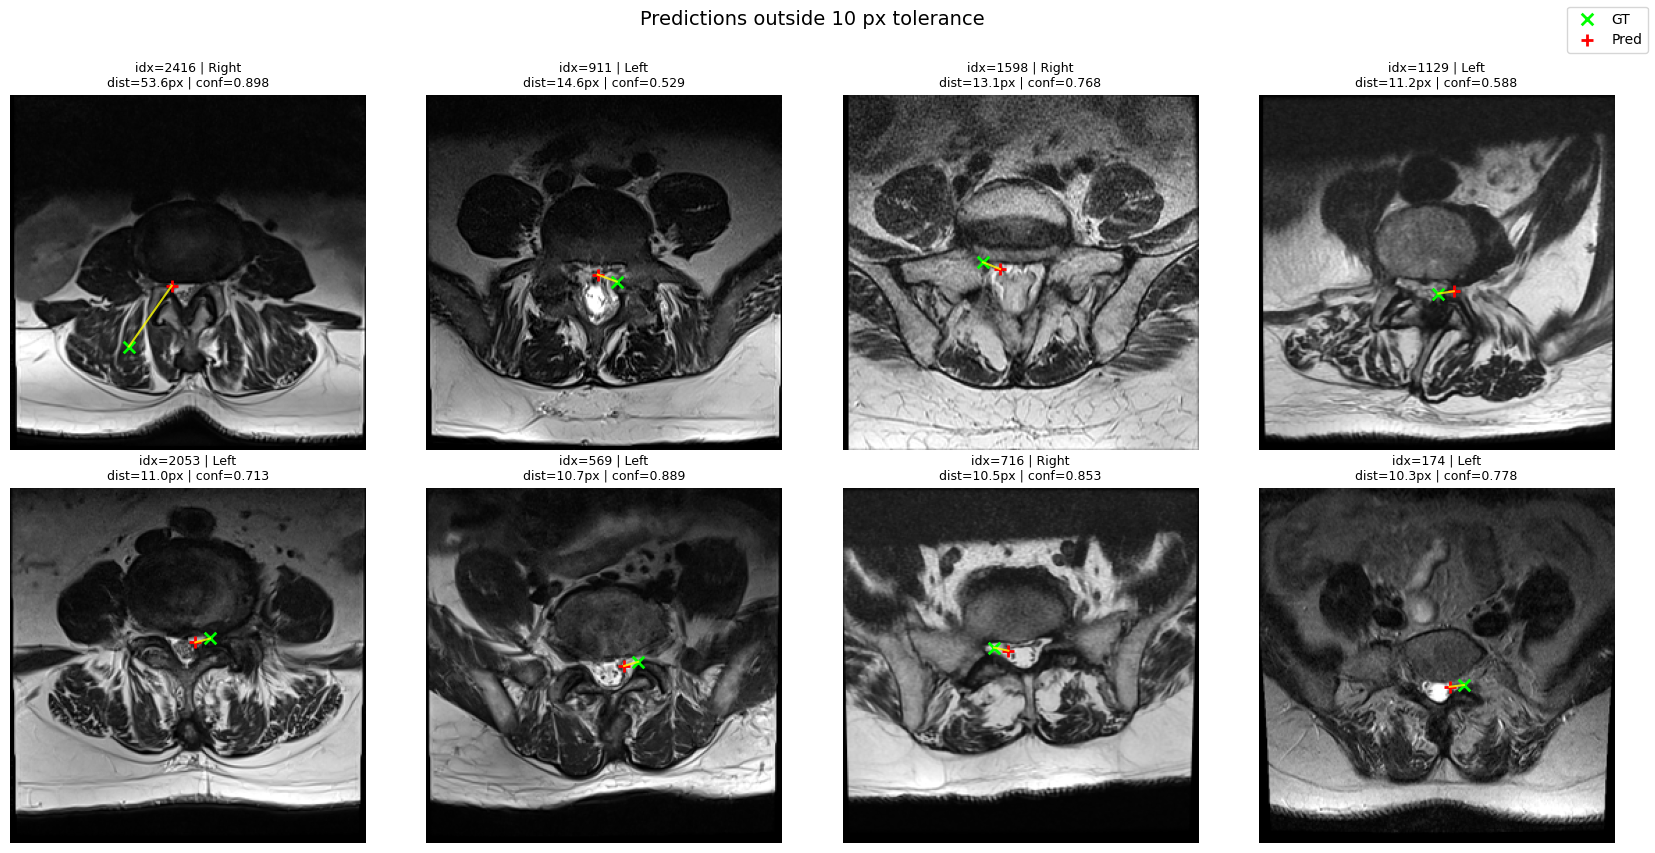

In [21]:
plot_prediction_misses(
    eval_df=test_raw_eval_df,
    dataset=test_ds,
    ncols=4,
    max_plots=None   # plot all misses
)

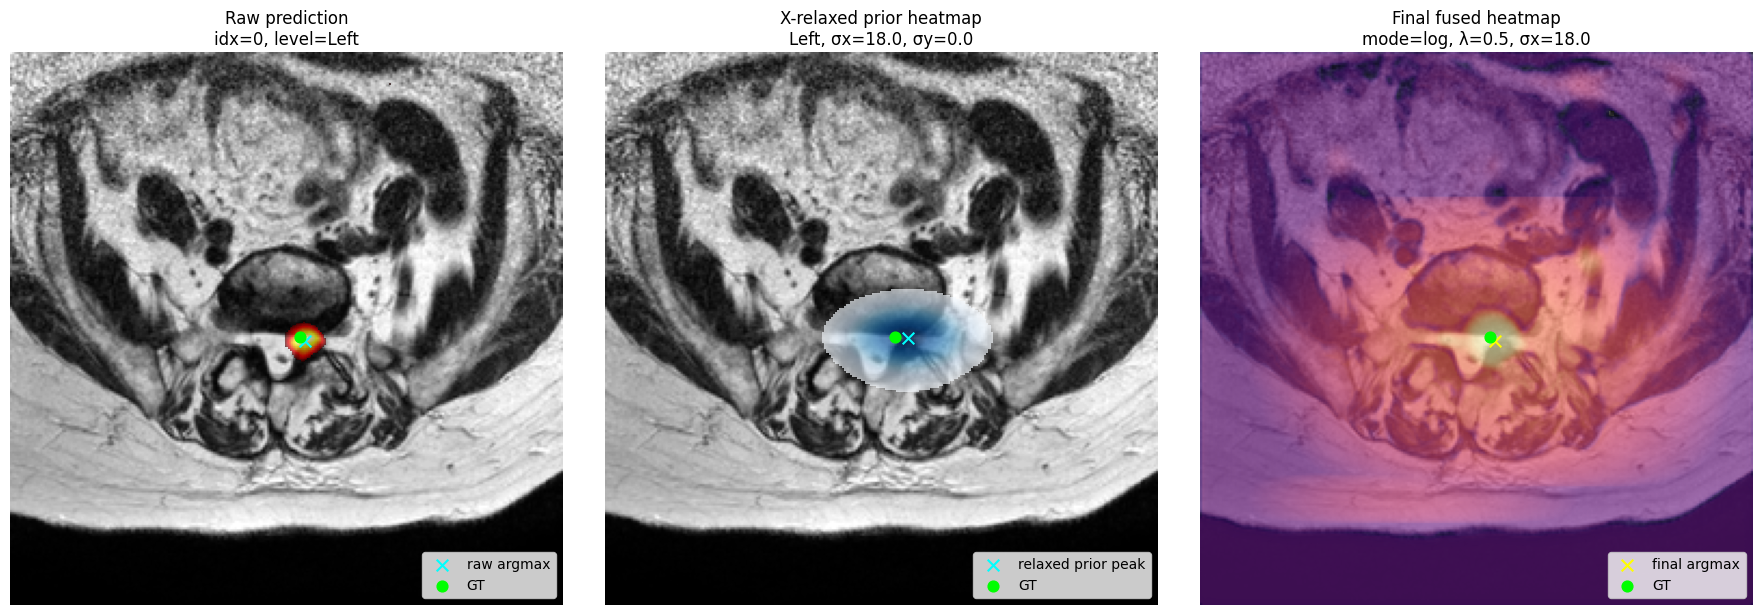

idx: 0
level: Left (level_idx=0)
GT point:     (133.93, 131.59)
Raw argmax:   (136.00, 133.00) conf=1.0000
Prior peak:   (140.00, 132.00) conf=1.0000
Final argmax: (136.00, 133.00) conf=1.0000


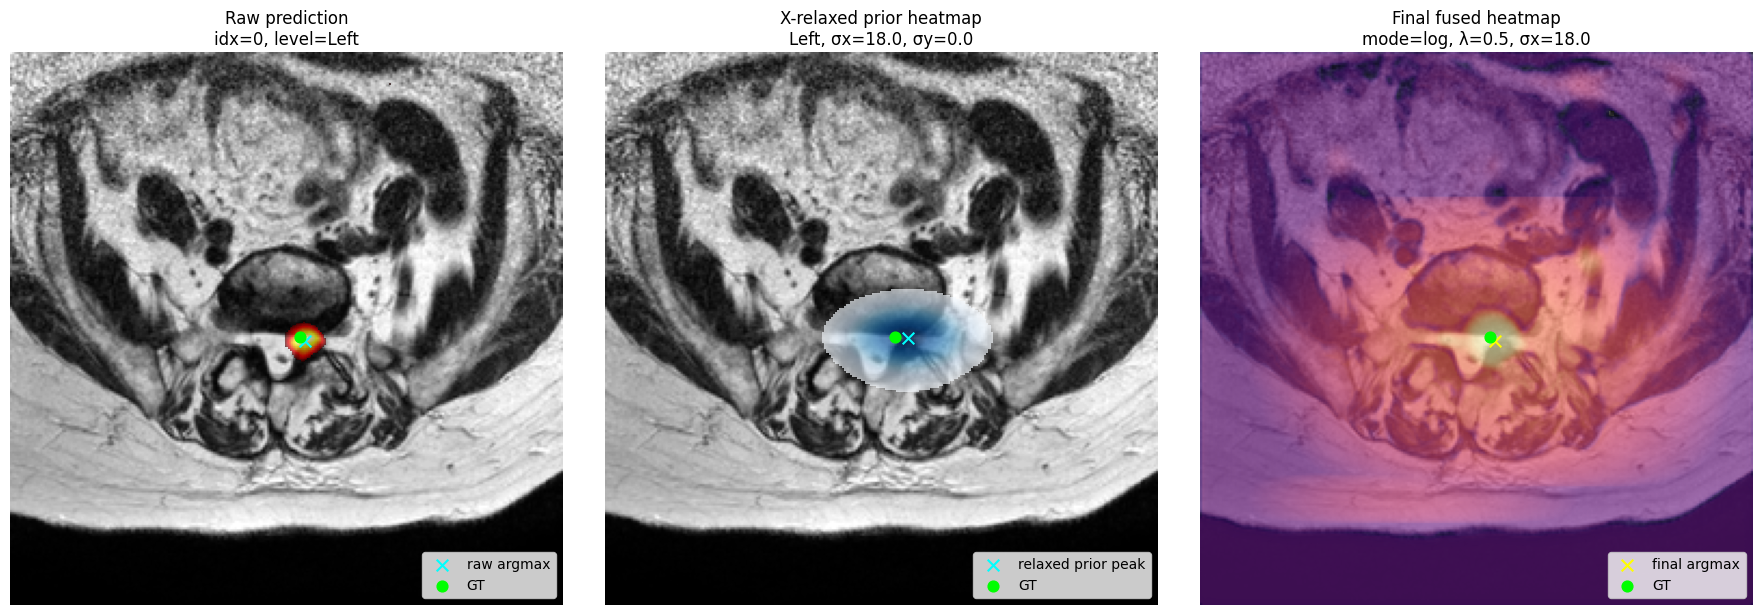

idx: 0
level: Left (level_idx=0)
GT point:     (133.93, 131.59)
Raw argmax:   (136.00, 133.00) conf=1.0000
Prior peak:   (140.00, 132.00) conf=1.0000
Final argmax: (136.00, 133.00) conf=1.0000


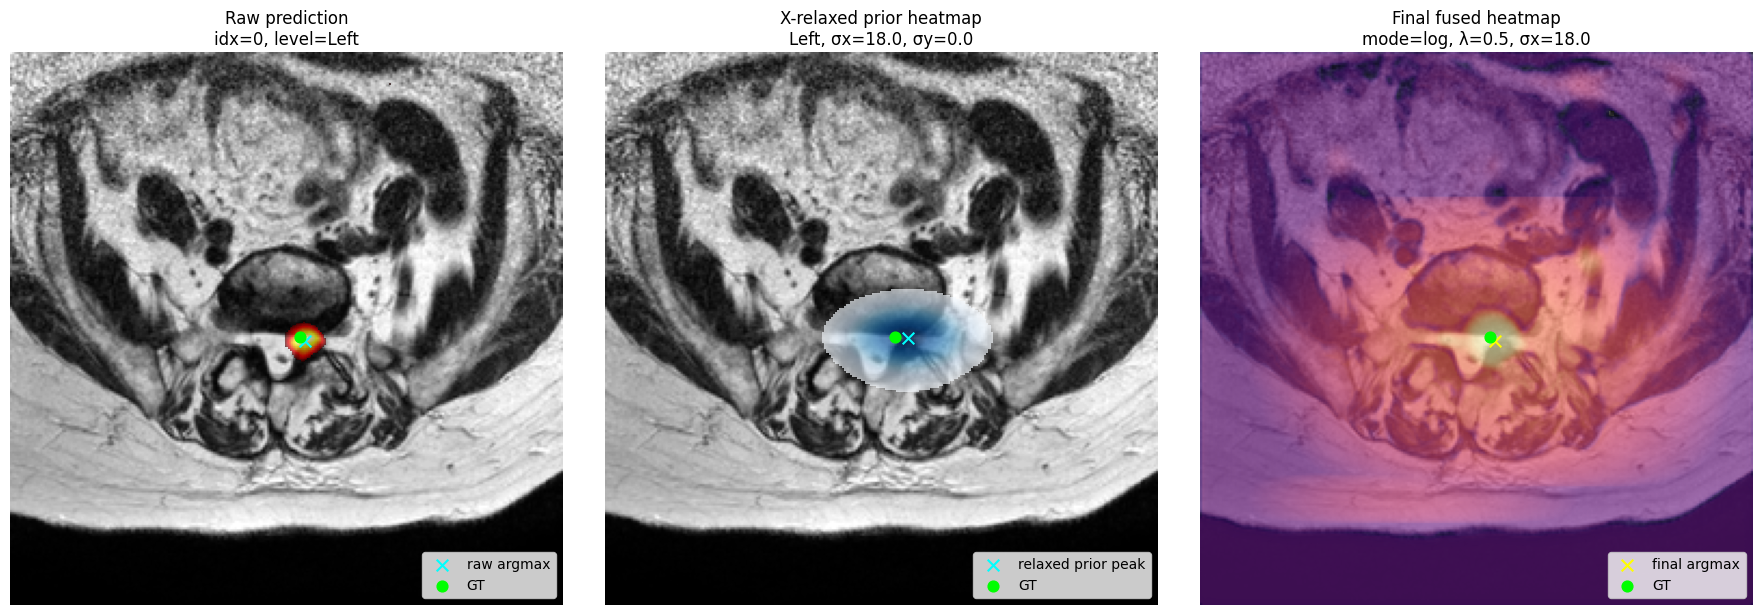

idx: 0
level: Left (level_idx=0)
GT point:     (133.93, 131.59)
Raw argmax:   (136.00, 133.00) conf=1.0000
Prior peak:   (140.00, 132.00) conf=1.0000
Final argmax: (136.00, 133.00) conf=1.0000


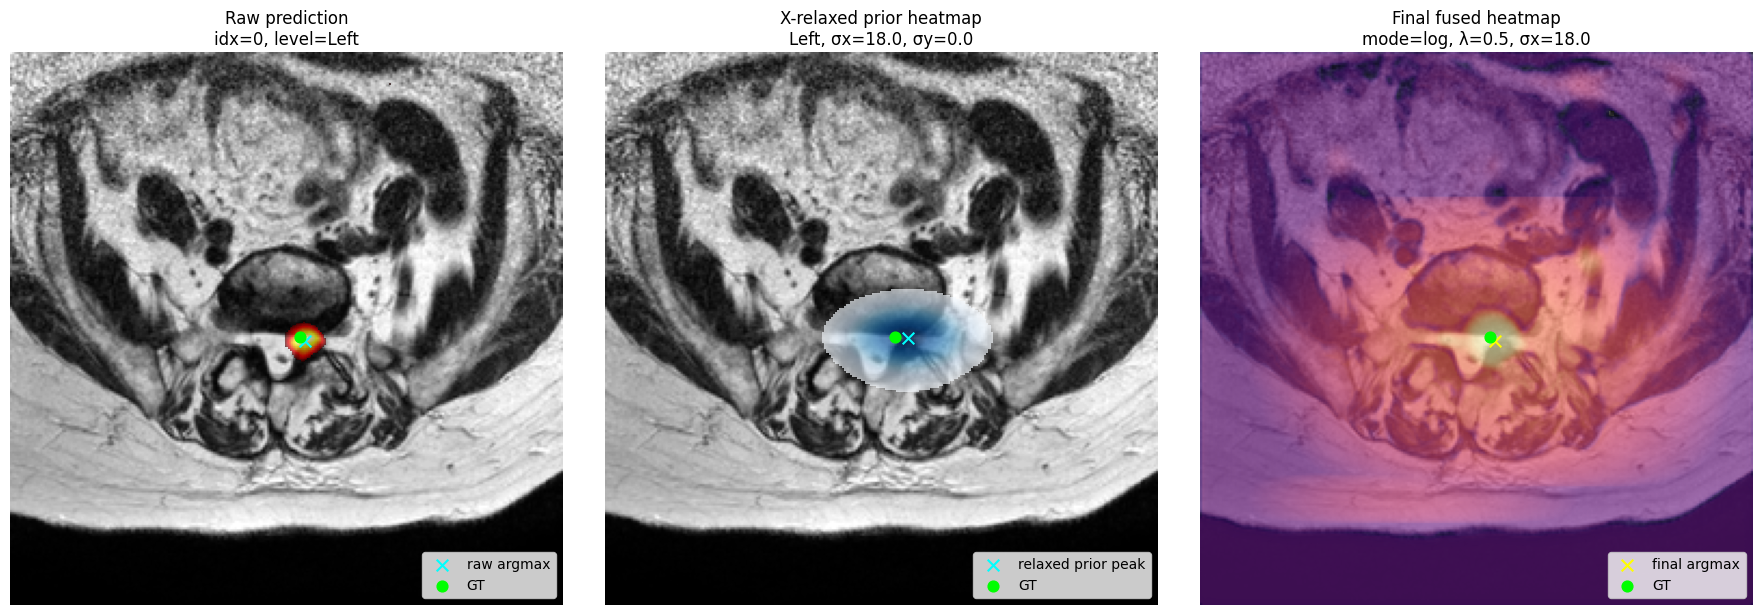

idx: 0
level: Left (level_idx=0)
GT point:     (133.93, 131.59)
Raw argmax:   (136.00, 133.00) conf=1.0000
Prior peak:   (140.00, 132.00) conf=1.0000
Final argmax: (136.00, 133.00) conf=1.0000


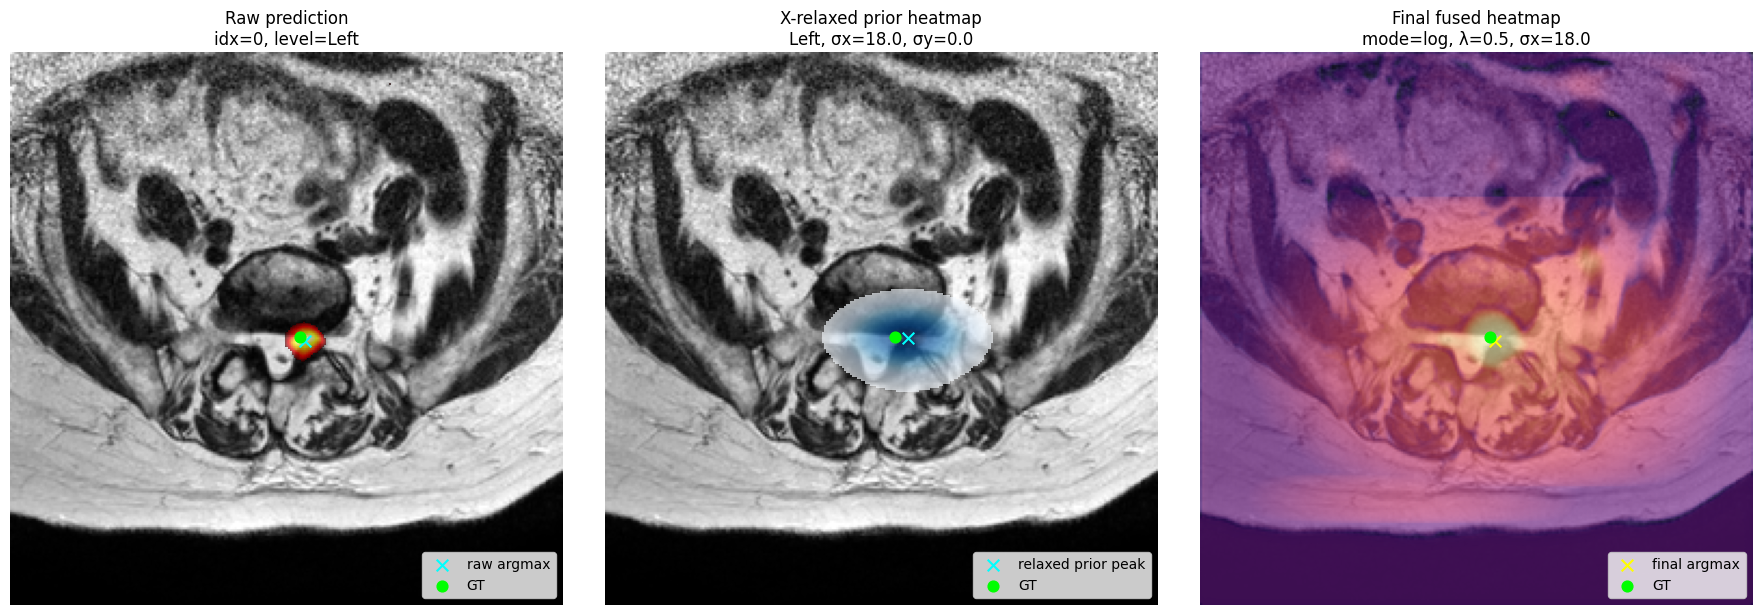

idx: 0
level: Left (level_idx=0)
GT point:     (133.93, 131.59)
Raw argmax:   (136.00, 133.00) conf=1.0000
Prior peak:   (140.00, 132.00) conf=1.0000
Final argmax: (136.00, 133.00) conf=1.0000


In [22]:
for idx in range(5):
    plot_raw_prior_final_masked(
    idx=0,
    dataset=test_ds,
    raw_preds=test_raw,
    prior_maps=PRIOR_MAPS,
    lam=0.5,
    eps=1e-8,
    fusion_mode="log",
    alpha=0.65,
    raw_threshold=0.25,
    prior_threshold=0.15,
    fused_threshold=0.25,
    prior_x_relax_sigma=18.0,
    prior_y_relax_sigma=0.0,
        
    )

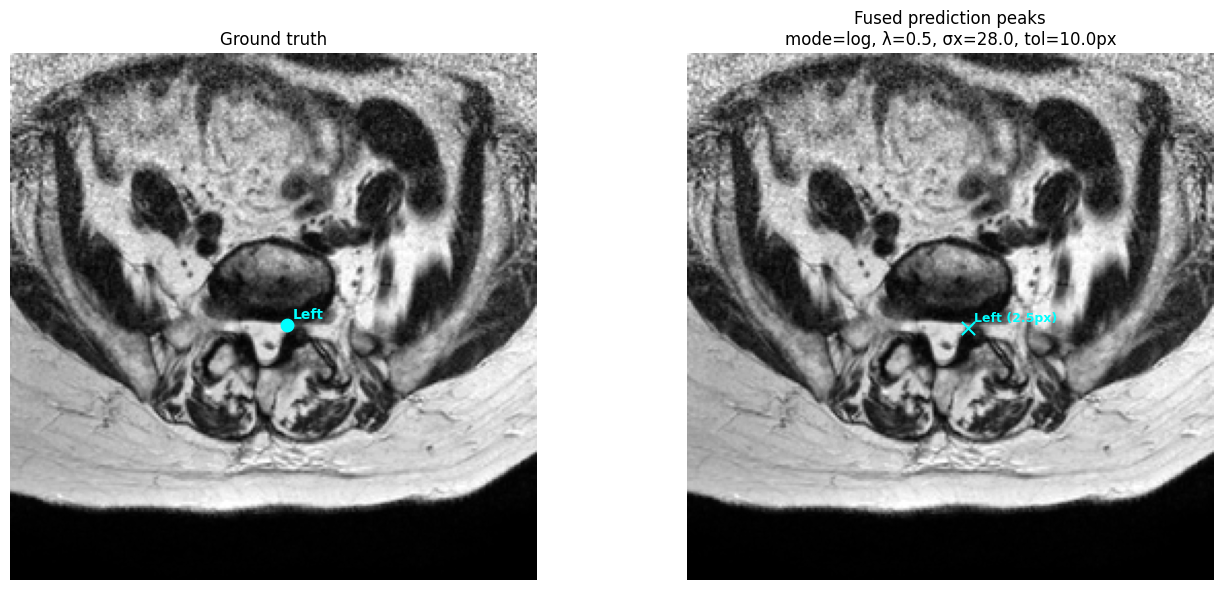

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 0
Matched rows: 1

Within 10.0px:
1 / 1


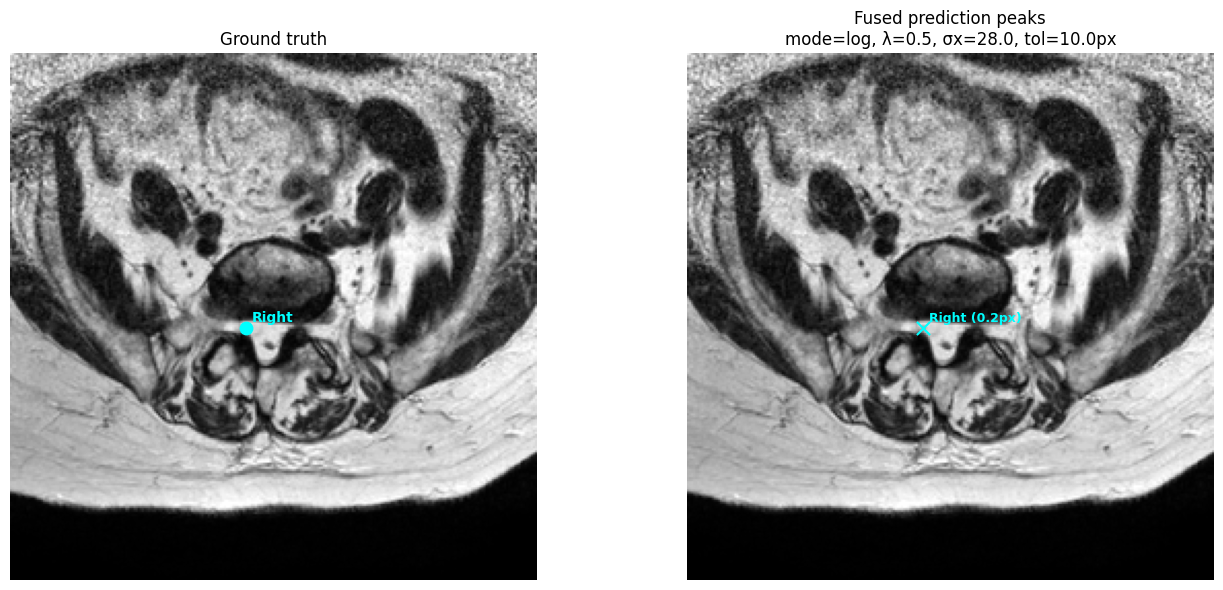

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 1
Matched rows: 1

Within 10.0px:
1 / 1


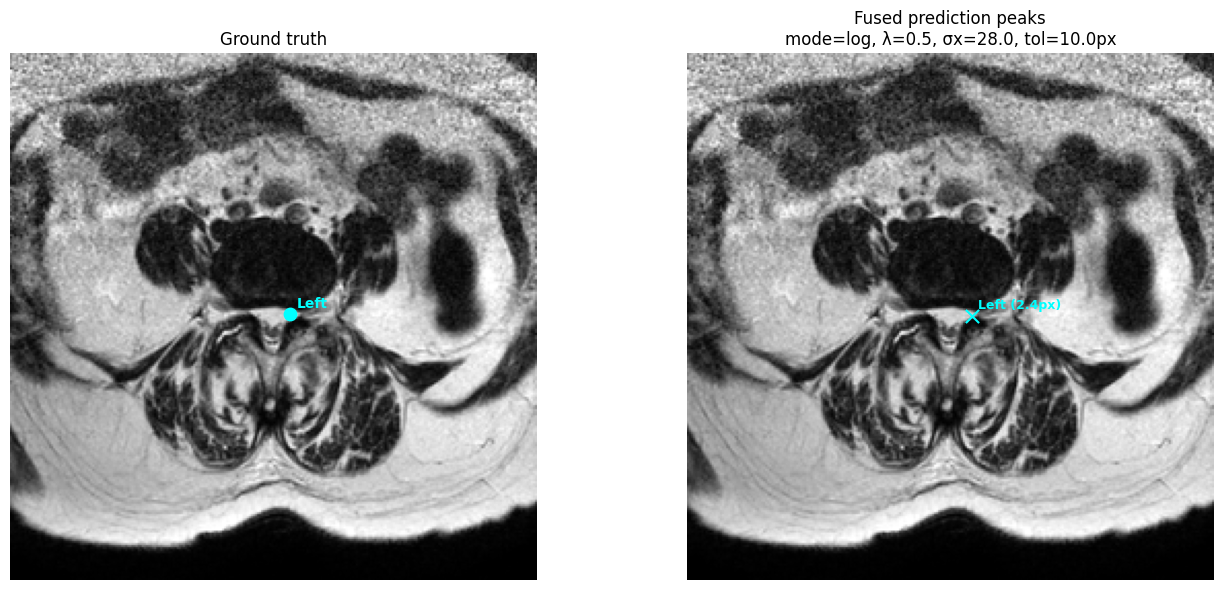

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 2
Matched rows: 1

Within 10.0px:
1 / 1


In [23]:
for anchor_idx in range(3):
    peak_df = plot_gt_vs_fused_peaks(
        anchor_idx=anchor_idx,
        dataset=test_ds,
        raw_preds=test_raw,
        prior_maps=PRIOR_MAPS,
        lam=FUSION_LAM,
        fusion_mode=FUSION_MODE,
        eps=FUSION_EPS,
        group_cols=None,
        prior_x_relax_sigma=PRIOR_X_RELAX_SIGMA,
        prior_y_relax_sigma=PRIOR_Y_RELAX_SIGMA,
        tolerance_px=EVAL_TOLERANCE_PX
        )

In [ ]:
TOL = EVAL_TOLERANCE_PX

rows = []
test_meta_df = test_ds.df.reset_index(drop=True)

for idx in range(len(test_ds)):
    sample = test_ds[idx]
    meta = test_meta_df.loc[idx].to_dict()

    # ground truth
    gt = sample["point_xy"]
    if hasattr(gt, "detach"):
        gt = gt.detach().cpu().numpy()

    gt_x, gt_y = float(gt[0]), float(gt[1])

    # level
    level_idx = int(test_raw["level_idx"][idx])
    level_name = LEVELS[level_idx]

    # raw + prior fusion
    raw_hmap = test_raw["heatmaps"][idx]
    prior_hmap = PRIOR_MAPS[level_idx]

    fused_score, fused_n, raw_n, prior_relaxed = _fuse_heatmap_with_scores(
        raw_hmap=raw_hmap,
        prior_hmap=prior_hmap,
        lam=FUSION_LAM,
        mode=FUSION_MODE,
        prior_x_relax_sigma=PRIOR_X_RELAX_SIGMA,
        prior_y_relax_sigma=PRIOR_Y_RELAX_SIGMA,
        eps=FUSION_EPS,
    )

    pred_x, pred_y, fused_score_at_pred = _argmax_xy_value(fused_score)

    dist_px = np.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)

    out = {
        "idx": idx,
        "level_idx": level_idx,
        "level": level_name,

        "gt_x": gt_x,
        "gt_y": gt_y,

        "pred_x": pred_x,
        "pred_y": pred_y,

        "dist_px": dist_px,
        "within_10px": dist_px <= TOL,
        "outside_10px": dist_px > TOL,
        "has_gt": True,
    }

    # stable merge metadata
    for c in [
        "study_id",
        "series_id",
        "instance_number",
        "condition",
        "series_description",
        "img_path",
    ]:
        if c in meta:
            out[c] = meta[c]

    rows.append(out)

test_eval_df = pd.DataFrame(rows)

In [ ]:
test_eval_df.groupby("level").agg(
    n=("dist_px", "size"),
    within_10px=("within_10px", "sum"),
    hit_rate=("within_10px", "mean"),
    mean_dist=("dist_px", "mean"),
    median_dist=("dist_px", "median"),
)